<a href="https://colab.research.google.com/github/00015775/learning-lab/blob/learn%2Fpytorch/pytorch/notebooks/02_experiment_timm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
try:
  from torchinfo import summary
  import timm
except ModuleNotFoundError as e:
  !pip3 install -q torchinfo
  !pip3 install -q timm
  import timm
  from torchinfo import summary

import torch
from torch import nn
import torchvision
from torchvision import datasets, models, transforms
import numpy as np
import time
import os
from PIL import Image
import matplotlib.pyplot as plt


## Loading Pretrained Model `timm`

In [2]:
device = torch.device("cuda" if torch.cuda.is_available()\
                      else "mps" if torch.backends.mps.is_available()\
                      else "cpu")

device

device(type='cpu')

In [3]:
# from IPython.display import clear_output

model_0 = timm.create_model("adv_inception_v3",
                            pretrained=True,
                            num_classes=56,
                            cache_dir="./models/")

model_0.eval()

/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name adv_inception_v3 to current inception_v3.tf_adv_in1k.
  model = create_fn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/95.5M [00:00<?, ?B/s]

InceptionV3(
  (Conv2d_1a_3x3): ConvNormAct(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNormAct2d(
      32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (Conv2d_2a_3x3): ConvNormAct(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (Conv2d_2b_3x3): ConvNormAct(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (Pool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): ConvNormAct(
    (conv): Conv2d(64, 80, kernel_size

In [4]:
model_0.training # evaluation mode is turned on

False

In [5]:
model_0.num_classes

56

In [6]:
for name, param in model_0.named_parameters():
  print(name, param.shape)

Conv2d_1a_3x3.conv.weight torch.Size([32, 3, 3, 3])
Conv2d_1a_3x3.bn.weight torch.Size([32])
Conv2d_1a_3x3.bn.bias torch.Size([32])
Conv2d_2a_3x3.conv.weight torch.Size([32, 32, 3, 3])
Conv2d_2a_3x3.bn.weight torch.Size([32])
Conv2d_2a_3x3.bn.bias torch.Size([32])
Conv2d_2b_3x3.conv.weight torch.Size([64, 32, 3, 3])
Conv2d_2b_3x3.bn.weight torch.Size([64])
Conv2d_2b_3x3.bn.bias torch.Size([64])
Conv2d_3b_1x1.conv.weight torch.Size([80, 64, 1, 1])
Conv2d_3b_1x1.bn.weight torch.Size([80])
Conv2d_3b_1x1.bn.bias torch.Size([80])
Conv2d_4a_3x3.conv.weight torch.Size([192, 80, 3, 3])
Conv2d_4a_3x3.bn.weight torch.Size([192])
Conv2d_4a_3x3.bn.bias torch.Size([192])
Mixed_5b.branch1x1.conv.weight torch.Size([64, 192, 1, 1])
Mixed_5b.branch1x1.bn.weight torch.Size([64])
Mixed_5b.branch1x1.bn.bias torch.Size([64])
Mixed_5b.branch5x5_1.conv.weight torch.Size([48, 192, 1, 1])
Mixed_5b.branch5x5_1.bn.weight torch.Size([48])
Mixed_5b.branch5x5_1.bn.bias torch.Size([48])
Mixed_5b.branch5x5_2.conv.wei

In [7]:
# trainable parameters
sum([p.numel() for p in model_0.parameters() if p.requires_grad == True])

21900312

In [8]:
for name, param in model_0.named_parameters():
  if "fc" in name:
    param.requires_grad_(True)
  else:
    param.requires_grad_(False)

In [9]:
# total parameters
sum([p.numel() for p in model_0.parameters()])

21900312

In [10]:
# trainable parameters
sum([p.numel() for p in model_0.parameters() if p.requires_grad == True])

114744

In [11]:
summary(model_0,
        (1,3,224,224),
        col_names=["input_size", "output_size"])

Layer (type:depth-idx)                   Input Shape               Output Shape
InceptionV3                              [1, 3, 224, 224]          [1, 56]
├─ConvNormAct: 1-1                       [1, 3, 224, 224]          [1, 32, 111, 111]
│    └─Conv2d: 2-1                       [1, 3, 224, 224]          [1, 32, 111, 111]
│    └─BatchNormAct2d: 2-2               [1, 32, 111, 111]         [1, 32, 111, 111]
│    │    └─Identity: 3-1                [1, 32, 111, 111]         [1, 32, 111, 111]
│    │    └─ReLU: 3-2                    [1, 32, 111, 111]         [1, 32, 111, 111]
├─ConvNormAct: 1-2                       [1, 32, 111, 111]         [1, 32, 109, 109]
│    └─Conv2d: 2-3                       [1, 32, 111, 111]         [1, 32, 109, 109]
│    └─BatchNormAct2d: 2-4               [1, 32, 109, 109]         [1, 32, 109, 109]
│    │    └─Identity: 3-3                [1, 32, 109, 109]         [1, 32, 109, 109]
│    │    └─ReLU: 3-4                    [1, 32, 109, 109]         [1, 32, 109, 

## Visualizing Feature Maps

In [12]:
def cosine_sim(x, y):
  return (x @ y)/(len(x) @ len(y))

In [13]:
from numpy import dot
from numpy.linalg import norm

def cosine_sim(x,y):
  return dot(x,y) / (norm(x)*norm(y))

# a = torch.randn(3, 2)
# b = torch.randn(3, 2)

# cosine_sim(a,b)

In [14]:
def cosine_sim(x, y):
  cos = nn.CosineSimilarity()
  return cos(x,y)

a = torch.randn(3, 2)
b = torch.randn(3, 2)

cosine_sim(a,b)

tensor([-0.9715, -0.6704,  0.9918])

In [15]:
import requests

url = "http://craphound.com/images/1006884_2adf8fc7.jpg"

response = requests.get(url)
if response == 200:
  with open("./random_images/", "wb") as f:
    f.write(response.content)
  print("Downloaded...")

In [16]:
import requests
from pathlib import Path

CAT_DIR = Path("./cat_data")
CAT_DIR.mkdir(parents=True, exist_ok=True)

cat_image_url = "https://i.guim.co.uk/img/media/327aa3f0c3b8e40ab03b4ae80319064e401c6fbc/377_133_3542_2834/master/3542.jpg?width=1200&height=1200&quality=85&auto=format&fit=crop&s=34d32522f47e4a67286f9894fc81c863"

response = requests.get(cat_image_url, stream=True)

if response.status_code == 200:
  with open("./cat_data/cat_image.jpg", "wb") as f:
    for chunk in response.iter_content(1024):
      f.write(chunk)
  print("Downloaded...")
else:
  print("Failed")

Downloaded...


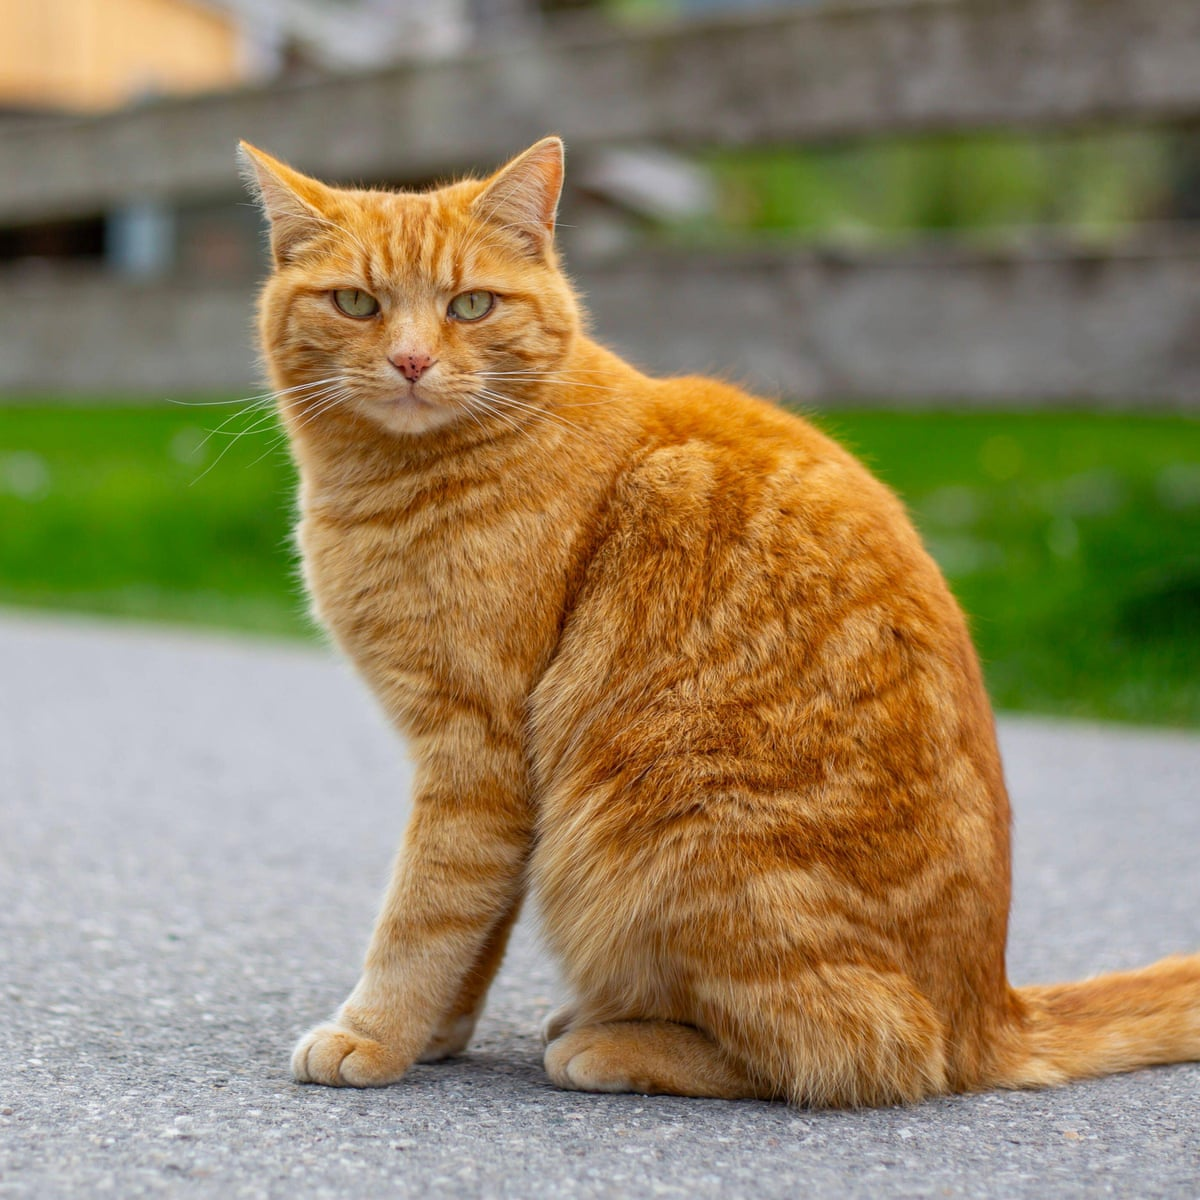

1200 1200


In [17]:
cat_image_path = "./cat_data/cat_image.jpg"

type(cat_image_path)

cat_image = Image.open(cat_image_path)

display(cat_image)
print(cat_image.height, cat_image.width)

In [18]:
type(cat_image)

PIL.JpegImagePlugin.JpegImageFile

In [19]:
cat_image_np = np.asarray(cat_image)

cat_image_np.shape

(1200, 1200, 3)

In [20]:
cat_image_np[0].max(), cat_image_np[1].max(), cat_image_np[2].max()

(np.uint8(246), np.uint8(246), np.uint8(246))

In [21]:
cat_image_np[0].min(), cat_image_np[1].min(), cat_image_np[2].min()

(np.uint8(18), np.uint8(18), np.uint8(18))

In [22]:
maxpool_nn = nn.Sequential(
    nn.MaxPool2d(kernel_size=5, padding=1, stride=1, dilation=5)#,
    # nn.MaxPool2d(kernel_size=4, padding=1, stride=1),
    # nn.MaxPool2d(kernel_size=5, padding=1, stride=1),
    # nn.MaxPool2d(kernel_size=6, padding=1, stride=1),
    #nn.MaxPool2d(kernel_size=20, padding=1, stride=1)
)

m = maxpool_nn(torch.from_numpy(cat_image_np).permute(2,1,0))

m.shape

/tmp/ipython-input-2832368790.py:9: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:206.)
  m = maxpool_nn(torch.from_numpy(cat_image_np).permute(2,1,0))


torch.Size([3, 1182, 1182])

(np.float64(-0.5), np.float64(1181.5), np.float64(1181.5), np.float64(-0.5))

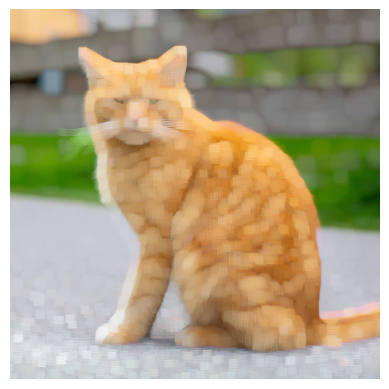

In [23]:
plt.imshow(m.permute(2,1,0))
plt.axis(False)

torch.Size([3, 111, 111])


(np.float64(-0.5), np.float64(110.5), np.float64(110.5), np.float64(-0.5))

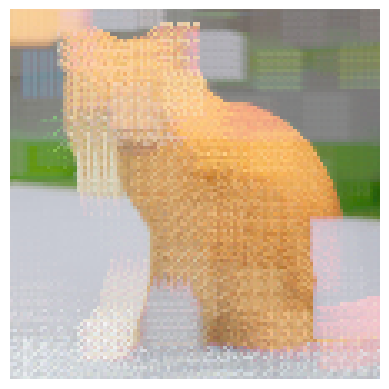

In [24]:
maxpool_nn = nn.Sequential(
    nn.MaxPool2d(kernel_size=5, padding=1, stride=10, dilation=25)
)

m = maxpool_nn(torch.from_numpy(cat_image_np).permute(2,1,0))

print(m.shape)

plt.imshow(m.permute(2,1,0))
plt.axis(False)

In [25]:
cat_image_np.shape, torch.from_numpy(cat_image_np).dtype

((1200, 1200, 3), torch.uint8)

In [26]:
torch.tensor(torch.from_numpy(cat_image_np,), dtype=torch.float32).dtype

/tmp/ipython-input-3439097745.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(torch.from_numpy(cat_image_np,), dtype=torch.float32).dtype


torch.float32

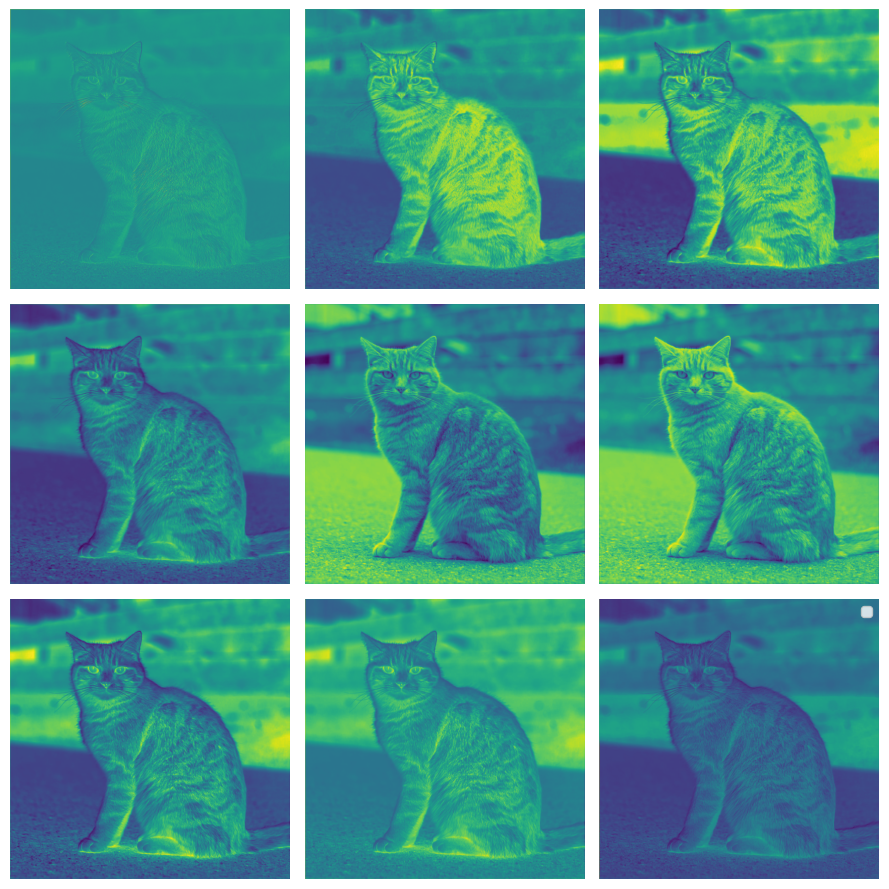

In [27]:
import math
import warnings

warnings.filterwarnings("ignore")

feature_maps_nn = nn.Conv2d(in_channels=3,
                            out_channels=9,
                            kernel_size=3,
                            stride=1,
                            padding=1,
                            dilation=1)

f = feature_maps_nn(torch.tensor(torch.from_numpy(cat_image_np).permute(2,1,0), dtype=torch.float))

n_maps = f.shape[0]

cols = math.ceil(math.sqrt(n_maps))
rows = math.ceil(n_maps/cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3))
axes = axes.flatten()

for i in range(n_maps):
  axes[i].imshow(f[i].permute(1,0).detach().numpy())
  axes[i].axis("off")

for i in range(n_maps, len(axes)):
  axes[i].axis("off")

plt.legend()
plt.tight_layout()
plt.show()

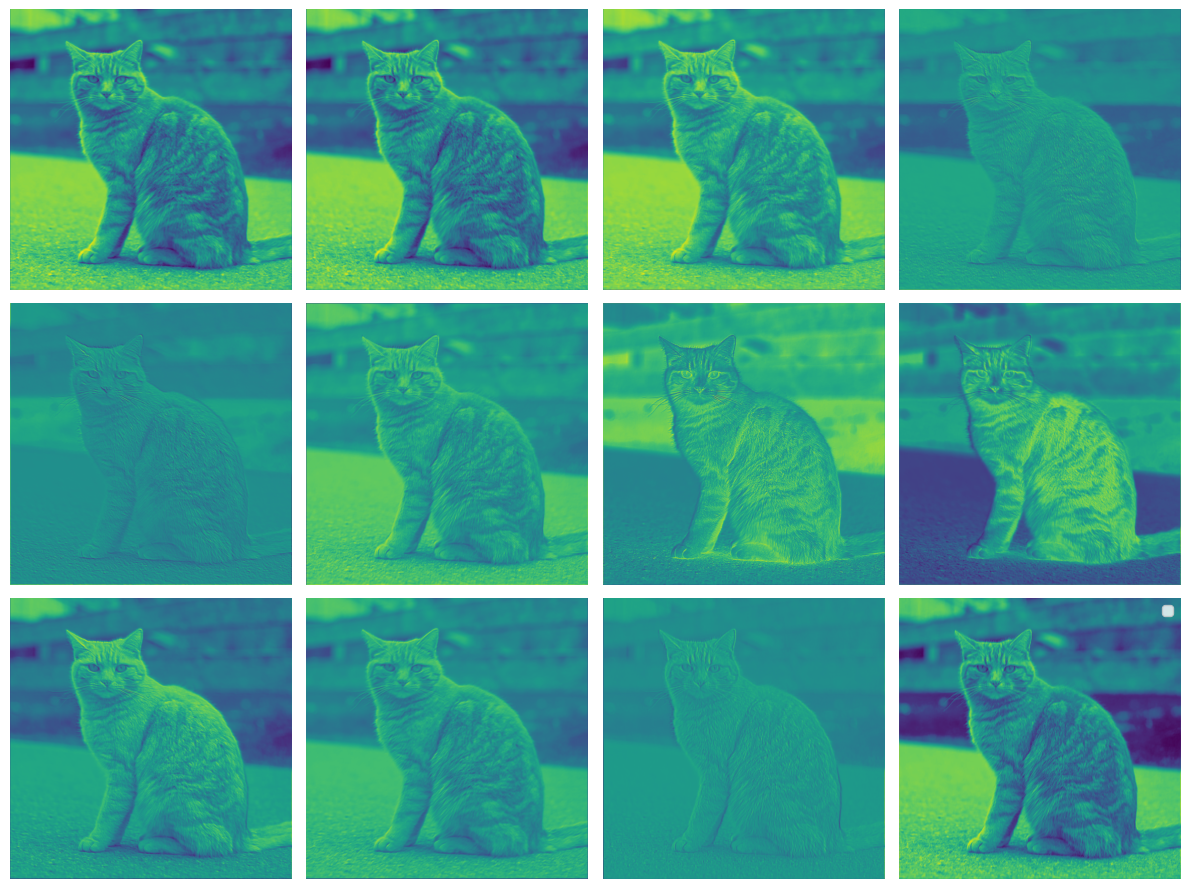

In [28]:
import math
import warnings

warnings.filterwarnings("ignore")

feature_maps_nn = nn.Sequential(
    nn.Conv2d(in_channels=3,
              out_channels=10,
              kernel_size=3,
              stride=1,
              padding=1,
              dilation=1),
    nn.Conv2d(in_channels=10,
              out_channels=40,
              kernel_size=3,
              stride=1,
              padding=1,
              dilation=1),
    nn.Conv2d(in_channels=40,
              out_channels=12,
              kernel_size=3,
              stride=1,
              padding=1,
              dilation=2),

)

f = feature_maps_nn(torch.tensor(torch.from_numpy(cat_image_np).permute(2,1,0), dtype=torch.float))

n_maps = f.shape[0]

cols = math.ceil(math.sqrt(n_maps))
rows = math.ceil(n_maps/cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3))
axes = axes.flatten()

for i in range(n_maps):
  axes[i].imshow(f[i].permute(1,0).detach().numpy())
  axes[i].axis("off")

for i in range(n_maps, len(axes)):
  axes[i].axis("off")

plt.legend()
plt.tight_layout()
plt.show()

(np.float64(-0.5), np.float64(1197.5), np.float64(1197.5), np.float64(-0.5))

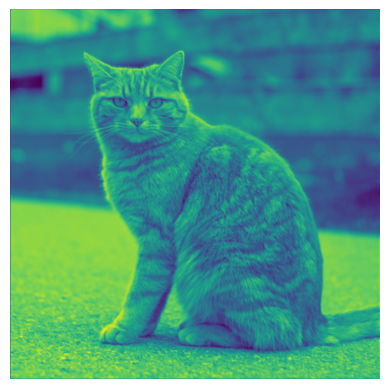

In [29]:
plt.imshow(f[1].permute(1,0).detach().numpy())
plt.axis(False)

(np.float64(-0.5), np.float64(1197.5), np.float64(1197.5), np.float64(-0.5))

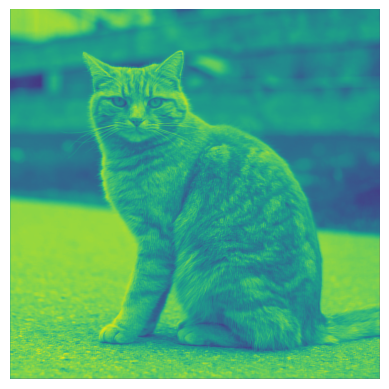

In [30]:
plt.imshow(f[2].permute(1,0).detach().numpy())
plt.axis(False)

In [31]:
import torch.nn.functional as F

print(f"\nConv output shape: {f[1].shape, f[2].shape}")

f1 = f[1].unsqueeze(0).detach().cpu()
f2 = f[2].unsqueeze(0).detach().cpu()

print(f"\nUnsqueeze(0) output shape: f1={f1.shape}, f2={f2.shape}")

f1 = f1.flatten(start_dim=1)
f2 = f2.flatten(start_dim=1)

print(f"\nFlattening output shape: {f1.shape, f2.shape}")

f1_norm = F.normalize(f1, p=2, dim=1)
f2_norm = F.normalize(f2, p=2, dim=1)

cos = torch.mm(f1_norm, f2_norm.T)

print(f"\nCosine Similarity: {cos.item():.4f}, Shape: {cos.shape}\n")


Conv output shape: (torch.Size([1198, 1198]), torch.Size([1198, 1198]))

Unsqueeze(0) output shape: f1=torch.Size([1, 1198, 1198]), f2=torch.Size([1, 1198, 1198])

Flattening output shape: (torch.Size([1, 1435204]), torch.Size([1, 1435204]))

Cosine Similarity: 0.9963, Shape: torch.Size([1, 1])



In [32]:
import torch.nn.functional as F

a = torch.arange(10.0, 20.0).reshape(5,2)

a, a.shape, a.min(), a.max()

(tensor([[10., 11.],
         [12., 13.],
         [14., 15.],
         [16., 17.],
         [18., 19.]]),
 torch.Size([5, 2]),
 tensor(10.),
 tensor(19.))

In [33]:
a = F.normalize(a)

a, a.shape, a.min(), a.max()

(tensor([[0.6727, 0.7399],
         [0.6783, 0.7348],
         [0.6823, 0.7311],
         [0.6854, 0.7282],
         [0.6877, 0.7260]]),
 torch.Size([5, 2]),
 tensor(0.6727),
 tensor(0.7399))

## Cosine Similarity of Feature Maps

In [34]:
def consine_sim(input: torch.Tensor):
  input = input.detach().numpy()

  return np.dot(input[1], input[2]) / (np.linalg.norm(input[1]) * np.linalg.norm(input[2]))

In [35]:
# single scalar value for cosine similarity
f1 = f[1].detach().numpy().flatten()
f2 = f[2].detach().numpy().flatten()

cos_sim = np.dot(a=f1, b=f2) / (np.linalg.norm(f1) * np.linalg.norm(f2))

cos_sim

np.float32(0.99631184)

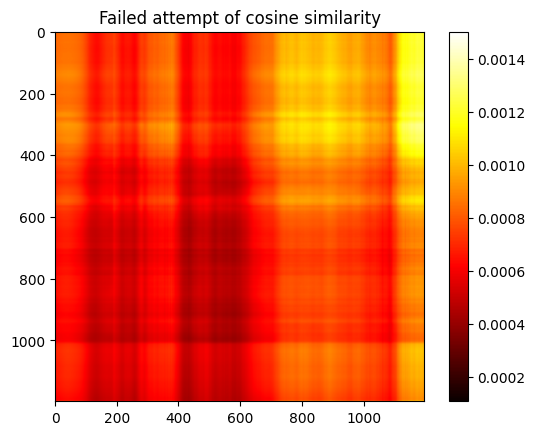

In [36]:
# heatmap
f1 = f[1].detach().numpy()
f2 = f[2].detach().numpy()

epsilon = 1e-6 # helps to avoid zero division
cos_sim = np.dot(f1, f2) / (np.linalg.norm(f1) * np.linalg.norm(f2) + epsilon)

plt.imshow(cos_sim, cmap="hot")
plt.title("Failed attempt of cosine similarity")
plt.colorbar()
plt.show()


Conv output shape: torch.Size([9, 1198, 1198])

Squeeze() output shape: torch.Size([9, 1198, 1198])

Shape after flattening: torch.Size([9, 1435204])

Stats BEFORE normalization: min=-63.1391, max=87.6581, std=18.4021

Stats AFTER normalization: min=-0.0039, max=0.0036, std=0.0008

Cosine similarity shape: torch.Size([9, 9])



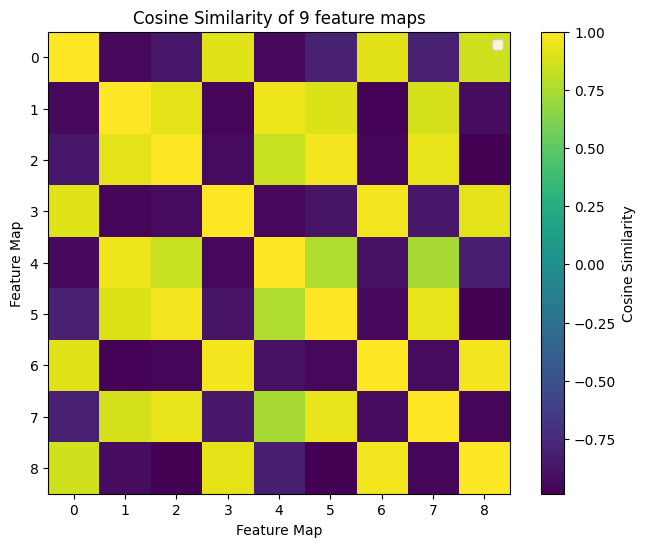

In [37]:
import math
import warnings

warnings.filterwarnings("ignore")

feature_maps_nn = nn.Sequential(
    nn.Conv2d(in_channels=3,
              out_channels=10,
              kernel_size=3,
              stride=1,
              padding=1,
              dilation=1),
    nn.Conv2d(in_channels=10,
              out_channels=40,
              kernel_size=3,
              stride=1,
              padding=1,
              dilation=1),
    nn.Conv2d(in_channels=40,
              out_channels=9,
              kernel_size=3,
              stride=1,
              padding=1,
              dilation=2),

)

img = torch.tensor(torch.from_numpy(cat_image_np).permute(2,1,0), dtype=torch.float)
f = feature_maps_nn(img)
print(f"\nConv output shape: {f.shape}")
f = f.squeeze(0)
print(f"\nSqueeze() output shape: {f.shape}")

n_maps = f.shape[0]

f_flat = f.view(n_maps, -1)
print(f"\nShape after flattening: {f_flat.shape}")

print(f"\nStats BEFORE normalization: min={f_flat.min():.4f}, max={f_flat.max():.4f}, std={f_flat.std():.4f}")
f_norm = F.normalize(f_flat, p=2, dim=1)
print(f"\nStats AFTER normalization: min={f_norm.min():.4f}, max={f_norm.max():.4f}, std={f_norm.std():.4f}")

cos_sim = torch.mm(f_norm, f_norm.T)

print(f"\nCosine similarity shape: {cos_sim.shape}\n") # 1.0: identical - 0.0: unrelated, -1.0:opposite activation

plt.figure(figsize=(8,6))
plt.imshow(cos_sim.detach().numpy(), cmap="viridis")
plt.colorbar(label="Cosine Similarity")
plt.title(f"Cosine Similarity of {f.shape[0]} feature maps")
plt.xlabel("Feature Map")
plt.ylabel("Feature Map")
plt.legend()
#plt.axis("off")
plt.show()


## Pytorch tutorial for Image Classification


**Source**: https://www.kaggle.com/code/hinepo/pytorch-tutorial-for-image-classification?scriptVersionId=237618061

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import time
import random
import os

from sklearn.model_selection import train_test_split

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam, AdamW, RMSprop # optimizers
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau

try:
  import albumentations as A
except ModuleNotFoundError:
  !pip3 install -U albumentations
  import albumentations as A

In [39]:
!pip install -q kaggle

Since we need to insert Kaggle API Token keys in order to be able to download the datasets from `Kaggle`, we will use `Secrets` in Google Colab.


**source**: https://www.kaggle.com/discussions/general/74235

**source**: https://readmedium.com/how-to-use-secrets-in-google-colab-450c38e3ec75

In [52]:
from google.colab import files, userdata

os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_API_TOKEN')
# os.environ["KAGGLE_API_TOKEN"] = userdata.get('KAGGLE_API_TOKEN')
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')

print(userdata.get("TESTING"))

Here i am testing to see the output of the Secrets of Colab


In [53]:
!kaggle competitions download -c digit-recognizer

digit-recognizer.zip: Skipping, found more recently modified local copy (use --force to force download)


In [54]:
!unzip digit-recognizer.zip

Archive:  digit-recognizer.zip
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


In [55]:
!kaggle competitions list

ref                                                                                 deadline             category                reward  teamCount  userHasEntered  
----------------------------------------------------------------------------------  -------------------  ---------------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/ai-mathematical-olympiad-progress-prize-3       2026-04-15 23:59:00  Featured         2,207,152 Usd       1869           False  
https://www.kaggle.com/competitions/vesuvius-challenge-surface-detection            2026-02-13 23:59:00  Research           200,000 Usd       1230           False  
https://www.kaggle.com/competitions/stanford-rna-3d-folding-2                       2026-03-25 23:59:00  Featured           100,000 Usd        739           False  
https://www.kaggle.com/competitions/med-gemma-impact-challenge                      2026-02-24 23:59:00  Featured           100,000 Usd        103           False  
https://ww

In [56]:
from pathlib import Path

KAGGLE_DATA_DIR = Path("./kaggle_datasets/")
KAGGLE_DATA_DIR.mkdir(parents=True, exist_ok=True)

In [57]:
!pwd

/content


In [58]:
!mv sample_submission.csv test.csv train.csv ./kaggle_datasets/

# move from ./content/ to ./content/kaggle_datasets/ folder

In [59]:
INPUT_PATH = "./kaggle_datasets/"
OUTPUT_PATH = "./"

train = pd.read_csv(INPUT_PATH + "train.csv")
test = pd.read_csv(INPUT_PATH + "test.csv")

print("Train shape:", {train.shape})
print("Test shape:", {test.shape})

print("\nTrain dataset:")
display(train)

print("\nTest dataset:")
display(test)


Train shape: {(42000, 785)}
Test shape: {(28000, 784)}

Train dataset:


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Test dataset:


,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [60]:
train.describe()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
count,42000.000000,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,...,42000.000000,42000.000000,42000.000000,42000.00000,42000.000000,42000.000000,42000.0,42000.0,42000.0,42000.0
mean,4.456643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.219286,0.117095,0.059024,0.02019,0.017238,0.002857,0.0,0.0,0.0,0.0
std,2.887730,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.312890,4.633819,3.274488,1.75987,1.894498,0.414264,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.00000,254.000000,62.000000,0.0,0.0,0.0,0.0


In [61]:
test.describe()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
count,28000.0,28000.0,28000.0,28000.0,28000.0,28000.0,28000.0,28000.0,28000.0,28000.0,...,28000.000000,28000.000000,28000.000000,28000.000000,28000.000000,28000.0,28000.0,28000.0,28000.0,28000.0
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.164607,0.073214,0.028036,0.011250,0.006536,0.0,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.473293,3.616811,1.813602,1.205211,0.807475,0.0,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,253.000000,254.000000,193.000000,187.000000,119.000000,0.0,0.0,0.0,0.0,0.0


In [62]:
train[:5]

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [63]:
test[:5]

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [64]:
print(f"Missing values in train dataset: {train.isnull().any().sum()}")
print(f"Missing values in test dataset: {test.isnull().any().sum()}")

Missing values in train dataset: 0
Missing values in test dataset: 0


In [65]:
train.columns

Index(['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5',
       'pixel6', 'pixel7', 'pixel8',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='object', length=785)

In [66]:
test.columns

Index(['pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6',
       'pixel7', 'pixel8', 'pixel9',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='object', length=784)

In [67]:
class CFG:
  DEBUG = False

  IMG_HEIGHT = 28
  IMG_WIDTH = 28
  N_CLASS = len(np.unique(train["label"]))

  # split train and validation sets
  split_fraction = 0.80

  # training
  print_freq = 100
  BATCH_SIZE = 1024
  N_EPOCHS = 3 if DEBUG else 10

  save_best_loss = False
  save_best_accuracy = True

  # optimizers
  optimizer = "adam"
  LEARNING_RATE = 1e-3 # 0.001
  weight_decay = 0.0 # for adamw
  penalty = 0.01     # for rmsprop
  rms_momentum = 0   # for rmsprop

  # learning rate scheduler
  scheduler = "CosineAnnealingLR"
  plateau_factor = 0.5
  plateau_patience = 0.3
  cosine_eta_min = 1e-7 # 0.00000001
  verbose = True

  # for albumentations
  probability = 0.10

  # for reproducibility
  random_seed= 986

In [68]:
if CFG.DEBUG:
  train = train.sample(frac = 0.5).reset_index(drop=True)
  CFG.N_CLASS = len(np.unique(train['label']))
  # CFG.N_CLASS = 10

In [69]:
print("DEBUG?: ", CFG.DEBUG)
print("Train shape:", train.shape)
print("Test shape:", test.shape)

print(f"\nImage shape (H, W): ({CFG.IMG_HEIGHT}, {CFG.IMG_WIDTH})")
print(f"Number of classes in train dataset: {CFG.N_CLASS}")

DEBUG?:  False
Train shape: (42000, 785)
Test shape: (28000, 784)

Image shape (H, W): (28, 28)
Number of classes in train dataset: 10


In [70]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


In [71]:
# for reproducibility
def seed_torch(seed):
  random.seed(seed)  # import random
  os.environ["PYTHONHASHSEED"] = str(seed) # python hash
  np.random.seed(seed)    # import numpy
  torch.manual_seed(seed) # import torch
  torch.cuda.manual_seed(seed)
  torch.backends.cudnn.deterministic = True

seed_torch(seed = CFG.random_seed)

In [72]:
train["label"]

,label
0,1
1,0
2,1
3,4
4,0
...,...
41995,0
41996,1
41997,7
41998,6


In [73]:
len(train.columns), len(test.columns) # train has one additional label column

(785, 784)

In [74]:
np.unique(train["label"])

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

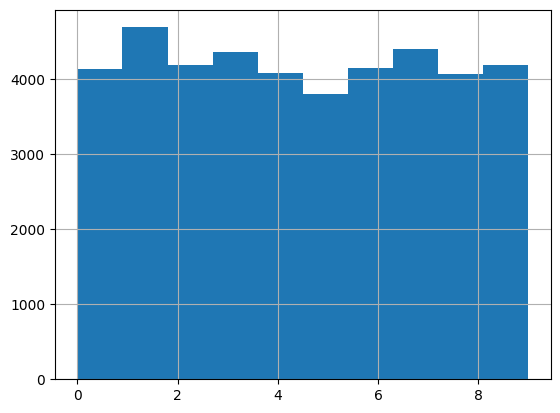

In [75]:
train["label"].hist(bins=CFG.N_CLASS)
plt.show()

In [76]:
print(f"Before split:\n train shape: {train.shape}\n test shape: {test.shape}")

train_df, valid_df = train_test_split(
    train,
    test_size = (1 - CFG.split_fraction),
    random_state = CFG.random_seed
)

print(f"\nAfter split:\n train_df shape: {train_df.shape}\n valid_df shape {valid_df.shape}")

Before split:
 train shape: (42000, 785)
 test shape: (28000, 784)

After split:
 train_df shape: (33600, 785)
 valid_df shape (8400, 785)


In [187]:
# for training and validation
class DigitDataset(torch.utils.data.Dataset):
  def __init__(self, df, X_col, y_col, augmentation=None):
      self.features = df[X_col].values.astype("float32") / 255.0
      self.targets = df[y_col].values
      self.augmentation = augmentation

  def __len__(self):
      return len(self.features)

  def __getitem__(self, idx):
      image = self.features[idx].reshape(28,28,1)
      label = torch.tensor(self.targets[idx], dtype=torch.long)

      if self.augmentation:
          image = self.augmentation(image=image)["image"]

      return image, label

# for inferencing
class DigitInferenceDataset(Dataset):
  def __init__(self, df, augmentation = None):
    self.features = df.values.astype("float32") / 255.0 # only features needed and no need for labels
    self.augmentation = augmentation

  def __len__(self):
    return len(self.features)

  def __getitem__(self, idx):
    image = self.features[idx].reshape(28,28,1)
    return image


In [195]:
import albumentations as A

transform_train = A.Compose(
    [
      A.Rotate(limit=40, p=CFG.probability),
      A.ShiftScaleRotate(rotate_limit=40, p=CFG.probability),
      A.Downscale(scale_min=0.7, scale_max=0.7, p=CFG.probability),
      A.pytorch.ToTensorV2()
    ]
)

transform_valid = A.Compose(
    [
      A.pytorch.ToTensorV2()
    ]
)

In [196]:
transform_train

Compose([
  Rotate(p=0.1, border_mode=0, crop_border=False, fill=0.0, fill_mask=0.0, interpolation=1, limit=(-40.0, 40.0), mask_interpolation=0, rotate_method='largest_box'),
  ShiftScaleRotate(p=0.1, shift_limit_x=(-0.0625, 0.0625), shift_limit_y=(-0.0625, 0.0625), scale_limit=(-0.09999999999999998, 0.10000000000000009), rotate_limit=(-40.0, 40.0), interpolation=1, border_mode=0, fill=0.0, fill_mask=0.0, rotate_method='largest_box', mask_interpolation=0),
  Downscale(p=0.1, interpolation_pair={'upscale': 0, 'downscale': 0}, scale_range=(0.25, 0.25)),
  ToTensorV2(p=1.0, transpose_mask=False),
], p=1.0, bbox_params=None, keypoint_params=None, additional_targets={}, is_check_shapes=True)

Length train dataset: 42000
Length train dataloader: 42
Batch size: 1024


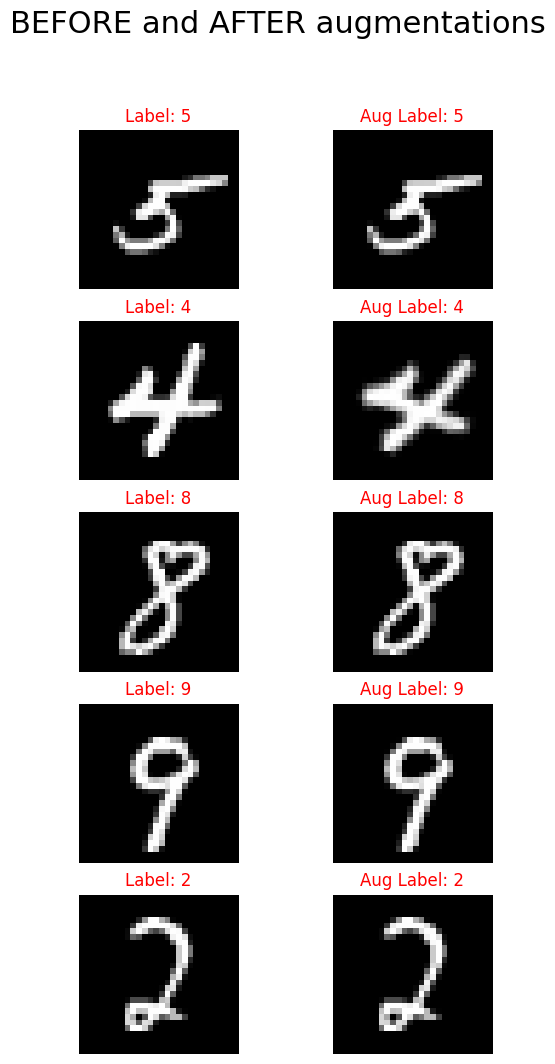

In [197]:
# testing if Dataset Class is working
y_col = "label"
X_col = [c for c in train.columns if c != "label"]

fig, ax = plt.subplots(5, 2, figsize=(6, 12))
fig.suptitle("BEFORE and AFTER augmentations", fontsize = 22)

td = DigitDataset(train, X_col, y_col, augmentation = None)
td_aug = DigitDataset(train, X_col, y_col, augmentation = transform_train)


tl = DataLoader(td, batch_size=CFG.BATCH_SIZE, shuffle=True)
tl_aug = DataLoader(td_aug, batch_size=CFG.BATCH_SIZE, shuffle=True)

print(f"Length train dataset: {len(td)}")
print(f"Length train dataloader: {len(tl)}")
print(f"Batch size: {CFG.BATCH_SIZE}")

begin = 40
end = begin + 5

for i in range(begin, end):
  for j in range(0,1):
    img, lab = td.__getitem__(begin + i)
    img_aug, lab_aug = td_aug.__getitem__(begin + i)

    # plot original image
    label = str(int(lab.item()))
    ax[i - begin, j].set_title("Label: " + label, color="red")
    ax[i - begin, j].imshow(np.squeeze(img), cmap="gray")
    ax[i - begin, j].axis(False)

    # plot augmented image
    ax[i - begin, j+1].set_title("Aug Label: " + label, color="red")
    ax[i - begin, j+1].imshow(np.squeeze(img_aug), cmap="gray")
    ax[i - begin, j+1].axis("off")


In [198]:
# checking batchnormalization
x = torch.arange(10.0,70.0,3).reshape(5,4)
print(f"std={torch.std(x):.4f}, mean={torch.mean(x)}")
print(x.shape)
print(x)

batchnorm = nn.BatchNorm1d(num_features=4)

out = batchnorm(x)
print(f"\nstd={torch.std(out):.4f}, mean={torch.mean(out)}")
print(out.shape)
print(out)


std=17.7482, mean=38.5
torch.Size([5, 4])
tensor([[10., 13., 16., 19.],
        [22., 25., 28., 31.],
        [34., 37., 40., 43.],
        [46., 49., 52., 55.],
        [58., 61., 64., 67.]])

std=1.0260, mean=1.4901161193847656e-08
torch.Size([5, 4])
tensor([[-1.4142e+00, -1.4142e+00, -1.4142e+00, -1.4142e+00],
        [-7.0711e-01, -7.0711e-01, -7.0711e-01, -7.0711e-01],
        [-7.4506e-09,  4.0978e-08,  8.9407e-08, -1.0058e-07],
        [ 7.0711e-01,  7.0711e-01,  7.0711e-01,  7.0711e-01],
        [ 1.4142e+00,  1.4142e+00,  1.4142e+00,  1.4142e+00]],
       grad_fn=<NativeBatchNormBackward0>)


In [199]:
# defning model
class DigitalModel(nn.Module):
  def __init__(self):
    super(DigitalModel, self).__init__()
    self.conv1 = nn.Conv2d(in_channels=1,
                           out_channels=32,
                           kernel_size=(5,5),
                           padding=0,
                           stride=1)
    self.actv = nn.LeakyReLU()
    self.batchnorm1 = nn.BatchNorm2d(num_features=32)
    self.maxpool = nn.MaxPool2d(kernel_size=(2,2)) # kernel_size=stride, non-overlapping
    self.dropout = nn.Dropout(p=0.25)
    self.conv2 = nn.Conv2d(in_channels=32,
                           out_channels=64,
                           kernel_size=(5,5),
                           padding=0,
                           stride=1)
    self.batchnorm2 = nn.BatchNorm2d(num_features=64)
    self.flatten = nn.Flatten()
    self.fc1 = nn.Linear(64 * 4 * 4, 256)
    self.batchnorm3 = nn.BatchNorm1d(num_features=256) #batchnorm1D for ndim=2
    self.classifer = nn.Linear(256, CFG.N_CLASS)

  def forward(self, x):
    # conv1 block
    x = self.conv1(x)
    x = self.actv(x)
    x = self.batchnorm1(x)
    x = self.maxpool(x)
    # x = self.dropout(x)

    # conv2 block
    x = self.conv2(x)
    x = self.actv(x)
    x = self.batchnorm2(x)
    x = self.maxpool(x)
    # x = self.dropout(x)

    # flatten
    x = self.flatten(x)

    x = self.fc1(x)
    x = self.batchnorm3(x)
    out = self.classifer(x)
    return out

In [200]:
def get_optimizer(model: torch.nn.Module, lr = CFG.LEARNING_RATE):
  if CFG.optimizer == "adam":
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=lr,
                                 weight_decay = CFG.weight_decay,
                                 amsgrad= False)
  elif CFG.optimizer == "adamw":
    optimizer = torch.optim.AdamW(model.parameters(),
                                  lr=lr,
                                  weight_decay = CFG.weight_decay
                                  )
  elif CFG.optimizer == "rmsprop":
    optimizer = torch.optim.RMSprop(model.parameters(),
                                  lr=lr,
                                  weight_decay = CFG.penalty,
                                  momentum = CFG.rms_momentum)
  else:
    print("Optimizer is not defined!")

  return optimizer

In [201]:
from torchinfo import summary

summary(DigitalModel().cpu(), (1, 1, 28, 28), col_names=["input_size", "output_size"])

Layer (type:depth-idx)                   Input Shape               Output Shape
DigitalModel                             [1, 1, 28, 28]            [1, 10]
├─Conv2d: 1-1                            [1, 1, 28, 28]            [1, 32, 24, 24]
├─LeakyReLU: 1-2                         [1, 32, 24, 24]           [1, 32, 24, 24]
├─BatchNorm2d: 1-3                       [1, 32, 24, 24]           [1, 32, 24, 24]
├─MaxPool2d: 1-4                         [1, 32, 24, 24]           [1, 32, 12, 12]
├─Conv2d: 1-5                            [1, 32, 12, 12]           [1, 64, 8, 8]
├─LeakyReLU: 1-6                         [1, 64, 8, 8]             [1, 64, 8, 8]
├─BatchNorm2d: 1-7                       [1, 64, 8, 8]             [1, 64, 8, 8]
├─MaxPool2d: 1-8                         [1, 64, 8, 8]             [1, 64, 4, 4]
├─Flatten: 1-9                           [1, 64, 4, 4]             [1, 1024]
├─Linear: 1-10                           [1, 1024]                 [1, 256]
├─BatchNorm1d: 1-11                 

In [202]:
def get_scheduler(optimizer: torch.optim.Optimizer):

  if CFG.scheduler == "ReduceLROnPlateau":
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode = "max",
        factor = CFG.plateau_factor,
        patience = CFG.plateau_patience,
        verbose = CFG.verbose

    )
  elif CFG.scheduler == "CosineAnnealingLR":
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max = CFG.N_EPOCHS,
        eta_min = CFG.cosine_eta_min
    )
  else:
    print("LR scheduler is not defined.")

  return scheduler

In [206]:
import time

def train_fn(train_loader: torch.utils.data.DataLoader,
             model: torch.nn.Module,
             criterion: torch.nn.Module,
             optimizer: torch.optim.Optimizer,
             device: torch.device = device):

  size = len(train_loader.dataset) # returns the total number of data points
  num_batches = len(train_loader)

  loss_list, correct = 0, 0

  model.train()

  for batch, (X, y) in enumerate(train_loader):
    start_time = time.time()

    optimizer.zero_grad()

    X, y = X.to(device), y.to(device)

    y_logits = model(X)
    loss = criterion(y_logits, y.long().squeeze())
    loss_list += (loss.item())

    current = batch * len(X)

    loss.backward()
    optimizer.step()

    # choose the highest pred value, choose CLASS DIMENSION
    y_pred, y_true = torch.argmax(y_logits, dim=1), y.long().squeeze()
    correct += (y_pred == y_true).type(torch.float).sum().item()

    end_time = time.time()
    time_delta = np.round(end_time - start_time, 3)

  # must be outside the batch loop for proper math
  batch_loss = loss_list / len(train_loader) # divide by number of batches and not total samples
  batch_correct = correct / len(train_loader)

  print(f"Batch: {current} | Train Acc: {batch_correct:.4f} | Train Loss: {batch_loss:.4f}")

  return batch_loss, batch_correct


In [207]:
def valid_fn(valid_loader, model, criterion, device):
  model.eval()

  size = len(valid_loader.dataset)
  num_batches = len(valid_loader)

  loss_list, correct = 0, 0

  with torch.inference_mode():
    for batch, (X, y) in enumerate(valid_loader):
      start = time.time()

      X, y = X.to(device), y.to(device)

      y_logits = model(X)
      loss = criterion(y_logits, y.long().squeeze())
      loss_list += loss.item()

      current = batch * len(X)

      y_pred, y_true = torch.argmax(y_logits, dim=1), y.long().squeeze()
      correct += torch.eq(y_pred, y_true).type(torch.float).sum().item()

      end = time.time()
      time_delta = np.round(end - start, 3)

  batch_loss = loss_list / len(valid_dataloader)
  batch_correct = correct / len(valid_dataloader)

  print(f"Valid Acc: {batch_correct:.4f} | Valid Loss: {batch_loss:.4f}")

  return batch_loss, batch_correct

In [208]:
from tqdm.auto import tqdm

start_time = time.time()

loss_fn = nn.CrossEntropyLoss()

model = DigitalModel().to(device)

optimizer = get_optimizer(model, lr = CFG.LEARNING_RATE)

scheduler = get_scheduler(optimizer)

y_col = "label"
X_col = [c for c in train.columns if c != "label"]

train_dataset = DigitDataset(
    train_df,
    X_col,
    y_col,
    augmentation= transform_train
)

valid_dataset = DigitDataset(
    valid_df,
    X_col,
    y_col,
    augmentation = transform_valid
)

train_dataloader = DataLoader(
    train_dataset,
    batch_size = CFG.BATCH_SIZE,
    shuffle = True
)

valid_dataloader = DataLoader(
    valid_dataset,
    batch_size = CFG.BATCH_SIZE,
    shuffle = False
)

train_loss_history = []
train_acc_history = []
valid_loss_history = []
valid_acc_history = []
LR_history = []

best_loss = np.inf
best_epoch_loss = 0
best_acc = 0
best_epoch_acc = 0

print("Starting Training ...\n")

for epoch in tqdm(range(0, CFG.N_EPOCHS)):
  print(f"\n-------------------------------   Epoch {epoch + 1}   -------------------------------\n")
  start_epoch_time = time.time()

  # train
  train_loss, train_acc = train_fn(train_dataloader,
                                  model,
                                  loss_fn,
                                  optimizer,
                                  device)
  train_loss_history.append(train_loss)
  train_acc_history.append(train_acc)

  # validation
  valid_loss, valid_acc = valid_fn(valid_dataloader,
                                  model,
                                  loss_fn,
                                  device)
  valid_loss_history.append(valid_loss)
  valid_acc_history.append(valid_acc)

  # apply LR scheduler after each epoch
  if isinstance(scheduler, ReduceLROnPlateau):
    scheduler.step()
  elif isinstance(scheduler, CosineAnnealingLR):
    scheduler.step()

  # save LR value to plot later
  for param_group in optimizer.param_groups:
    LR_history.append(param_group["lr"])

  # save validation loss if it was improved (reduced)
  if valid_loss < best_loss:
    best_epoch_loss = epoch + 1
    best_loss = valid_loss
    if CFG.save_best_loss:
      torch.save(model.state_dict(), OUTPUT_PATH + f"DigitModel_ep{best_epoch_loss}.pth")

  # save validation accuracy if it was improved (increased)
  if valid_acc > best_acc:
    best_epoch_acc = epoch + 1
    best_acc = valid_acc
    if CFG.save_best_accuracy:
      torch.save(model.state_dict(), OUTPUT_PATH + f"DigitalModel_ep{best_epoch_acc}.pth")

  end_epoch_time = time.time()
  time_delta = np.round(end_epoch_time - start_epoch_time, 3)
  print(f"\n\nEpoch Elapsed Time: {time_delta}")

end_train_time = time.time()
print(f"\n\nTotal Elapsed Time: {np.round((end_train_time - start_time)/60, 3)} minutes")
print("Done!")



Starting Training ...



  0%|          | 0/10 [00:00<?, ?it/s]


-------------------------------   Epoch 1   -------------------------------

Batch: 26624 | Train Acc: 883.8485 | Train Loss: 0.4260
Valid Acc: 814.2222 | Valid Loss: 0.5698


Epoch Elapsed Time: 74.509

-------------------------------   Epoch 2   -------------------------------

Batch: 26624 | Train Acc: 964.6667 | Train Loss: 0.1691
Valid Acc: 915.5556 | Valid Loss: 0.0865


Epoch Elapsed Time: 86.429

-------------------------------   Epoch 3   -------------------------------

Batch: 26624 | Train Acc: 975.6061 | Train Loss: 0.1348
Valid Acc: 915.8889 | Valid Loss: 0.0616


Epoch Elapsed Time: 75.14

-------------------------------   Epoch 4   -------------------------------

Batch: 26624 | Train Acc: 981.5758 | Train Loss: 0.1170
Valid Acc: 919.4444 | Valid Loss: 0.0558


Epoch Elapsed Time: 66.359

-------------------------------   Epoch 5   -------------------------------

Batch: 26624 | Train Acc: 984.8788 | Train Loss: 0.1062
Valid Acc: 920.4444 | Valid Loss: 0.0526


Epoch El

In [209]:
images, labels = next(iter(train_dataloader))
print(images.shape)

torch.Size([1024, 1, 28, 28])


In [210]:
print(f"Best loss: {round(best_loss, 5)}")
print(f"Best epoch (according to loss): {best_epoch_loss}")
print("\n")
print(f"Best accuracy: {round(best_acc, 5)}")
print(f"Best epoch (accuracy criteria): {best_epoch_acc}")

Best loss: 0.0445
Best epoch (according to loss): 10


Best accuracy: 922.44444
Best epoch (accuracy criteria): 10


## Transfer Learning with `timm`

**Source**: https://www.kaggle.com/code/hinepo/transfer-learning-with-timm-models-and-pytorch

In [211]:
# continue on another notebook